# AB-Testing-Project
## Experiment Overview: Free Trial Screener  

At the time of this experiment, Udacity courses currently have two options on the course overview page: "start free trial", and "access course materials". If the student clicks "start free trial", they will be asked to enter their credit card information, and then they will be enrolled in a free trial for the paid version of the course. After 14 days, they will automatically be charged unless they cancel first. If the student clicks "access course materials", they will be able to view the videos and take the quizzes for free, but they will not receive coaching support or a verified certificate, and they will not submit their final project for feedback.


In the experiment, Udacity tested a change where if the student clicked "start free trial", they were asked how much time they had available to devote to the course. If the student indicated 5 or more hours per week, they would be taken through the checkout process as usual. If they indicated fewer than 5 hours per week, a message would appear indicating that Udacity courses usually require a greater time commitment for successful completion, and suggesting that the student might like to access the course materials for free. At this point, the student would have the option to continue enrolling in the free trial, or access the course materials for free instead. This screenshot shows what the experiment looks like.

<img src="Experiment_Screenshot.png">

## 1. Experiment Design
### 1.1 Unit of Diversion (provided by Udacity)
The unit of diversion is a **cookie**, although if the student enrolls in the free trial, they are tracked by user-id from that point forward. The same user-id cannot enroll in the free trial twice. For users that do not enroll, their user-id is not tracked in the experiment, even if they were signed in when they visited the course overview page.

### 1.2 Initial Hypothesis 
The hypothesis was that this might set clearer expectations for students upfront, thus **reducing the number of frustrated students who left the free trial** because they didn't have enough time—without significantly reducing the number of students to continue past the free trial and eventually complete the course. If this hypothesis held true, Udacity could improve the overall student experience and improve coaches' capacity to support students who are likely to complete the course. (Provided by Udacity)  
  
Based on the information above, we can set some initial hypotheis: (these are just initial hypothesis and we will revise them further)

  1. H0: The change has no effect on the probability of students enrolling in the free trial.
     H1: The change reduces the probability of students enrolling in the free trial.
   
   
  2. H0: The change has no effect on the probability of students leaving the free trial.
     H1: The change reduces the probability of students leaving the free trial.

    *(we use probability instead of counts here, because it is better measure for groups of unequal sizes)

### 1.3 Metric Choice
there are seven choices from Udacity below.

- **Number of cookies**: That is, number of unique cookies to view the course overview page. (dmin=3000)
- **Number of user-ids**: That is, number of users who enroll in the free trial. (dmin=50)
- **Number of clicks**: That is, number of unique cookies to click the "Start free trial" button (which happens before the free trial screener is trigger). (dmin=240)
- **Click-through-probability**: That is, number of unique cookies to click the "Start free trial" button divided by number of unique cookies to view the course overview page. (dmin=0.01)
- **Gross conversion**: That is, number of user-ids to complete checkout and enroll in the free trial divided by number of unique cookies to click the "Start free trial" button. (dmin= 0.01)

dmin means the practical significance boundary for each metric, that is, the difference that would have to be observed before that was a meaningful change for the business, is given in parentheses. All practical significance boundaries are given as absolute changes.

# Metric Choices 



### Invariant Metrics
The **metrics we don't expect to change between treatment and control groups** are listed below. These are known as **invariant metrics**, as they are independent of the experimental treatment. While it might be sufficient to use only the **click-through probability** (since it is derived from the other two), tracking the individual components is helpful for diagnostics if unexpected variations occur.

| **Metric**                    | **Formula / Definition**                                                             | **Minimum Detectable Effect (d<sub>min</sub>)** |
|------------------------------|----------------------------------------------------------------------------------------|-----------------------------------------------|
| **Number of Cookies**        | Number of unique daily cookies that view the course overview page                     | 3000                                          |
| **Number of Clicks**         | Number of unique daily cookies that click the "Start Free Trial" button               | 240                                           |
| **Click-through Probability**| Number of clicks/ Number of cookies                                                                     | 0.01                                          |


### Evaluation Metrics Expected to Vary (Variant Metrics)

In contrast to the invariant metrics, we expect the following metrics to be affected by the treatment and vary between the control and treatment groups:

- **Gross Conversion**  
  We expect the gross conversion rate in the treatment group to be **lower** than in the control group.  
  This is because the treatment aims to divert users who are unlikely to be a good fit for the paid course (e.g., users with a time commitment of less than 5 hours/week) towards the free course materials. These users are more likely to churn, so excluding them should lower the initial conversion rate.

- **Retention**  
  At the same time, we expect the **retention rate to increase**.  
  This is because users who are not serious or have low time commitment would be filtered out by the treatment, leaving only more committed users in the paid trial.

- **Number of User-IDs**  
  We also expect the number of user-ids (i.e., users who enroll in the free trial; with a minimum detectable effect of -50) to **decrease**.  
  However, since this metric is not normalized and doesn’t provide insights beyond what is already captured in the gross conversion (which controls for the number of clicks), we will **not use it as a primary evaluation metric**.



| **Metric**                    | **Formula / Definition**                                                             | **Minimum Detectable Effect (d<sub>min</sub>)** |
|------------------------------|----------------------------------------------------------------------------------------|-----------------------------------------------|
| **Gross Conversion**        | Number of  user-ids that enrolled / Number of clicks                     | -0.01                                          |
| **Retention**         | Number of user-ids that paid/ Number of user-ids that enrolled               | 0.01                                           |               |


### Hypothesis Revised
Based on the metrics we choose and the initial hypothesis, we can revise our hypothesis.

 1. H0: Gross Conversion(control) = Gross Conversion(treatment)  
    H1: Gross Conversion(control) != Gross Conversion(treatment)
 2. H0: Retention(control) = Retention(treatment)  
    H1: Retention(control) != Retention(treatment)

# Import data

## baseline values

This csv file below contains rough estimates of the baseline values for the mentioned metrics as given by Udacity 

In [10]:
#import packages
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

#import csv file
baseline = pd.read_csv('data/Final Project Baseline Values.csv', header=None)
baseline

,0,1
0,Unique cookies to view course overview page pe...,40000.000000
1,"Unique cookies to click ""Start free trial"" per...",3200.000000
2,Enrollments per day:,660.000000
3,"Click-through-probability on ""Start free trial"":",0.080000
4,"Probability of enrolling, given click:",0.206250
5,"Probability of payment, given enroll:",0.530000
6,"Probability of payment, given click",0.109313


In [11]:
baseline = baseline[baseline[0] != 'Probability of payment, given click']

In [12]:
baseline

,0,1
0,Unique cookies to view course overview page pe...,40000.00000
1,"Unique cookies to click ""Start free trial"" per...",3200.00000
2,Enrollments per day:,660.00000
3,"Click-through-probability on ""Start free trial"":",0.08000
4,"Probability of enrolling, given click:",0.20625
5,"Probability of payment, given enroll:",0.53000


In [13]:
# adjust the dataset 
baseline.columns = ['Metrics','Estimator']
baseline['Metrics'] = ['cookies', 'cliks', 'user-id','click-through-probability','gross conversion','retention']
baseline['dmin'] = [3000, 240, -50, 0.01, -0.01, 0.01]
baseline

C:\Users\niran\AppData\Local\Temp\ipykernel_9828\2044909512.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline['Metrics'] = ['cookies', 'cliks', 'user-id','click-through-probability','gross conversion','retention']
C:\Users\niran\AppData\Local\Temp\ipykernel_9828\2044909512.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline['dmin'] = [3000, 240, -50, 0.01, -0.01, 0.01]


,Metrics,Estimator,dmin
0,cookies,40000.00000,3000.00
1,cliks,3200.00000,240.00
2,user-id,660.00000,-50.00
3,click-through-probability,0.08000,0.01
4,gross conversion,0.20625,-0.01
5,retention,0.53000,0.01


## Assumption  

Now, we can calculate the standard deviation of gross conversion and retention. And there is an assumption that we should make. For the two probability metrics, we assume their distributions are approximately normal (binomial distribution) because the scaled estimators are large (Central Limit Theorem). 

However, if we are not sure. We can also test it using the normal approximation, i.e np>10 and np(1-p)>10

In [15]:
# the normal approximation function
def normal_A(n,p,metric):
    if 10 < n*p and 10 < n*(1-p):
        print(metric,":  n =", n, "is valid")
    else:
        print(metric,":  n =", n, "is not valid")

# check 
# remember the sample size for different metrics are different
for i,j in zip([1,2],[4,5]):
    normal_A (baseline.loc[i, "Estimator"], baseline.loc[j,"Estimator"], baseline.loc[j,"Metrics"])

gross conversion :  n = 3200.0 is valid
retention :  n = 660.0 is valid


**Notice:** Since the denominator for gross conversion and net conversion is the number of clicks, which is also the unit of diversion, we can expect their analytical variance is close to the empirical variance. However, for the rentention, we recommend to collect an empirical variance. Based on the difference between the denominator and the unit of diversion, we could expect the empirical variance of the retention would be higher than the analyticaal variance.

# Sizing

## Choosing Number of Samples given Power

### calculation

We set the alpha to be 0.05 and the statistical power to be 0.80 (i.e. beta is 0.20).  
And we applied an online caculator:

gross conversion:
<img src="figure/gross_conversion.png">

retention:
<img src="figure/retention.png">

Therefore, we can calculate how many pageviews we need for each metric:

1. Gross Conversion 
  - Baseline Conversion: 20.625%
  - Minimum Detectable Effect: 1%
  - Alpha: 5%
  - Beta: 20% 
  - Sample Size = 25,835 enrollments/group
  - Number of groups = 2 (experiment & control)
  - Total sample size = 2*25,835 = 51,670 clicks
  - Clicks/Pageview: 3200/40000 = 0.08 clicks/pageview
  - Pageviews Required = 51,670/0.08 = 645,875  
  
  
2. Retention 
  - Baseline Conversion: 53.000%
  - Minimum Detectable Effect: 1%
  - Alpha: 5%
  - Beta: 20% 
  - Sample Size = 39,115 enrollments/group
  - Number of groups = 2 (experiment & control)
  - Total sample size = 2*39,115 = 78,230 enrollments
  - user-id(enrollments)/Pageview: 660/40000 = 0.0165 enrollments/pageview
  - Pageviews Required = 78,230/0.0165 = 4,741,212  

In [17]:
# inset column
baseline['samplesize'] = [np.nan,np.nan,np.nan,np.nan,645875,4741212]

baseline

C:\Users\niran\AppData\Local\Temp\ipykernel_9828\3054331036.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline['samplesize'] = [np.nan,np.nan,np.nan,np.nan,645875,4741212]


,Metrics,Estimator,dmin,samplesize
0,cookies,40000.00000,3000.00,NaN
1,cliks,3200.00000,240.00,NaN
2,user-id,660.00000,-50.00,NaN
3,click-through-probability,0.08000,0.01,NaN
4,gross conversion,0.20625,-0.01,645875.0
5,retention,0.53000,0.01,4741212.0


Given the calculation above, to test two three hypothesis, we need 4,741,212 pageviews.

### multiple hypothesis?

As we now have three hypothesis, and these three hypothesis are not fully independent. So the false positive rate is likely to be increased. We can solve the multiple hypothesis problem by Bonferroni Correction method, but it still has backward that it will increase the fale negatives. Therefore, we prefer not to solving this problem.

## Choosing Duration vs. Exposure

From the Udacity, given there are 40k pageviews per day, we can first assume we can use 100% of users for this experiment.

In [19]:
# gross conversion, retention and net conversion
print('for the experiment with gross conversion and retention we need: ', 
      round(4741212/40000),' days')

# gross conversion and net conversion
print('for the experiment with gross conversion, we need: ', 
      round(685875/40000),' days')

for the experiment with gross conversion and retention we need:  119  days
for the experiment with gross conversion, we need:  17  days


**Notice:** We can see there is a huge difference in experiment duration between using and discarding retention. Therefore, we decide to remove the retention metric for this experiment. Because firstly, using the retention metric will take a long time to conduct this experiment, which will cause opportunity costs(eg. launch more different experiments, spend more time on other feature improvements). Moreover, there will be some business risks that exist if we use the retention metric. For instance, this change will give a worse user experiment decreasing the conversion rate.

Also, for the experiment with gross conversion and net conversion, we should reconsider the fraction of Udacity's traffic to be diverted. Considering there might be some seasonal effect for this experiment, 17 days seems not enough for us to certain. Secondly, using full traffic is very costly and risky (opportunity cost & business risk we mentioned above). Diverting a half or lower of traffic will be much safer.

In [20]:
# gross conversion and net conversion
# 50% traffic
print('for the experiment using 50% traffic with gross conversion and net conversion, we need: ', 
      round(685875/(40000*0.5)),' days')

# gross conversion and net conversion
# 45% traffic
print('for the experiment using 45% traffic with gross conversion and net conversion, we need: ', 
      round(685875/(40000*0.45)),' days')

for the experiment using 50% traffic with gross conversion and net conversion, we need:  34  days
for the experiment using 45% traffic with gross conversion and net conversion, we need:  38  days


It seems that 38 days are little bit longer, so we will divert 50% traffic for the experiment with gross conversion and net conversion.

# Analysis

Now, we have two datasets from Udacity, one for control group and one for experiment group.

The meaning of each column is:

- Pageviews: Number of unique cookies to view the course overview page that day.
- Clicks: Number of unique cookies to click the course overview page that day.
- Enrollments: Number of user-ids to enroll in the free trial that day.
- Payments: Number of user-ids who who enrolled on that day to remain enrolled for 14 days and thus make a payment. (Note that the date for this column is the start date, that is, the date of enrollment, rather than the date of the payment. The payment happened 14 days later. Because of this, the enrollments and payments are tracked for 14 fewer days than the other columns.)

In [21]:
# import dataset
control = pd.read_csv('data/Final Project Results - Control.csv')
experiment = pd.read_csv('data/Final Project Results - Experiment.csv')
control.head()

,Date,Pageviews,Clicks,Enrollments,Payments
0,"Sat, Oct 11",7723,687,134.0,70.0
1,"Sun, Oct 12",9102,779,147.0,70.0
2,"Mon, Oct 13",10511,909,167.0,95.0
3,"Tue, Oct 14",9871,836,156.0,105.0
4,"Wed, Oct 15",10014,837,163.0,64.0


In [22]:
experiment.head()

,Date,Pageviews,Clicks,Enrollments,Payments
0,"Sat, Oct 11",7716,686,105.0,34.0
1,"Sun, Oct 12",9288,785,116.0,91.0
2,"Mon, Oct 13",10480,884,145.0,79.0
3,"Tue, Oct 14",9867,827,138.0,92.0
4,"Wed, Oct 15",9793,832,140.0,94.0


In [23]:
# the duration for this experiment 
print('control group duration:\n', control.count())
print('experiment group duration:\n', experiment.count())

control group duration:
 Date           37
Pageviews      37
Clicks         37
Enrollments    23
Payments       23
dtype: int64
experiment group duration:
 Date           37
Pageviews      37
Clicks         37
Enrollments    23
Payments       23
dtype: int64


In [24]:
# calculate the sample size for this dataset that Udacity provide us
print('control size: ' , control['Pageviews'].sum())
print('experiment size: ' , experiment['Pageviews'].sum())
print('sample size: ' , control['Pageviews'].sum()+experiment['Pageviews'].sum())

control size:  345543
experiment size:  344660
sample size:  690203


Seems the control group size are larger than the experiment group size, we will figure out whether this difference within our expectations in future.  
Now, we can make some visualizations to make a clear comparison between control and experiment groups.

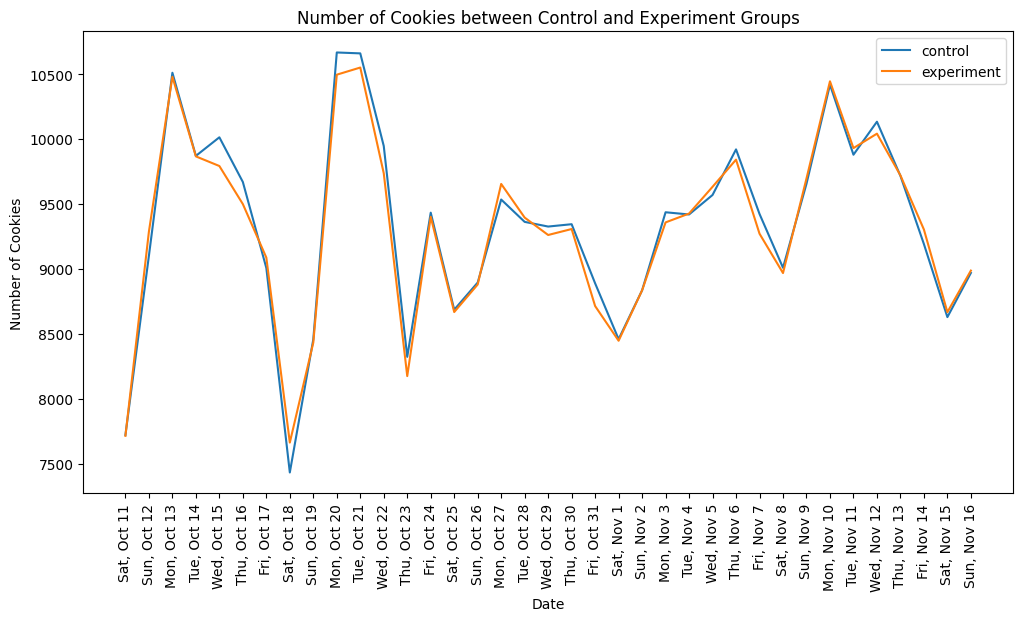

In [25]:
# invariant: Number of cookies
plt.figure(figsize=(12,6))
x = control['Date']
line1 = plt.plot(x ,control['Pageviews'],label = 'control')
line2 = plt.plot(x ,experiment['Pageviews'], label = 'experiment')
plt.xticks(rotation = 90)
plt.xlabel('Date')
plt.ylabel('Number of Cookies')
plt.title('Number of Cookies between Control and Experiment Groups')
plt.legend()

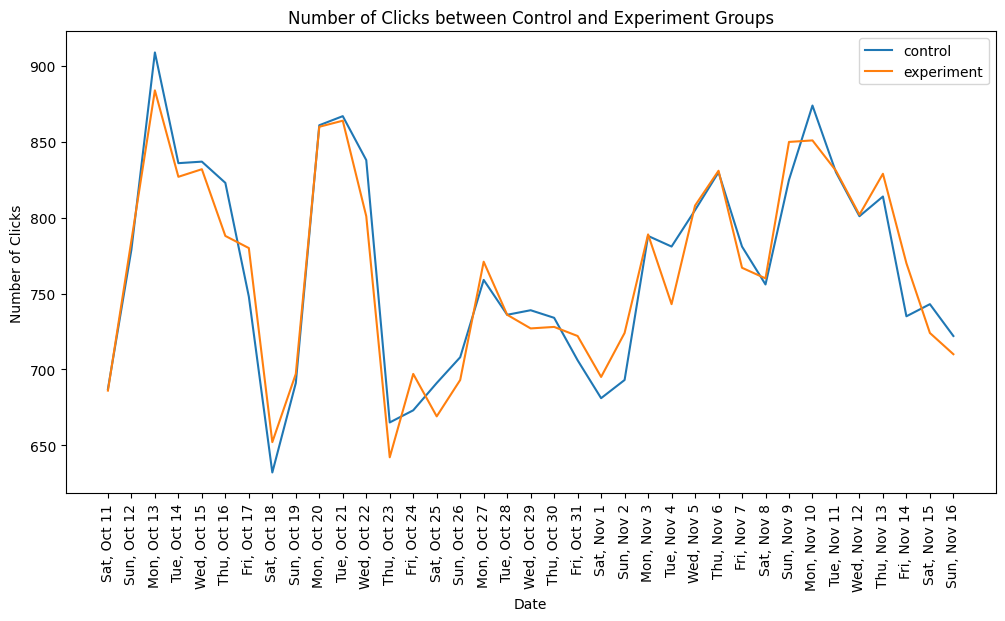

In [26]:
# invariant: Number of clicks
plt.figure(figsize=(12,6))
x = control['Date']
line1 = plt.plot(x ,control['Clicks'],label = 'control')
line2 = plt.plot(x ,experiment['Clicks'], label = 'experiment')
plt.xticks(rotation = 90)
plt.xlabel('Date')
plt.ylabel('Number of Clicks')
plt.title('Number of Clicks between Control and Experiment Groups')
plt.legend()

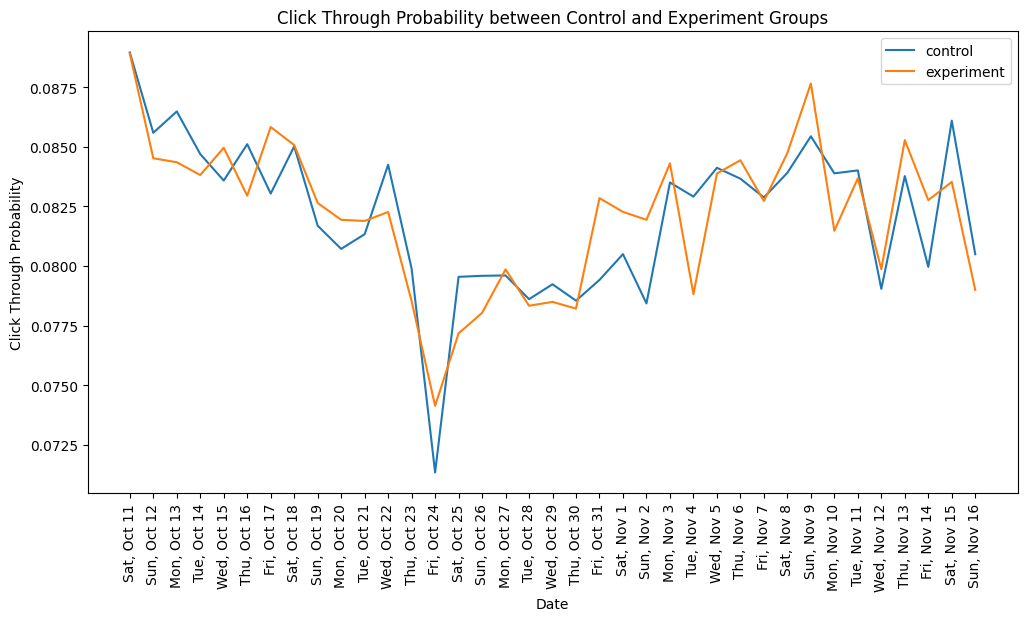

In [27]:
# invariant: click through probability (Number of clicks / Number of cookies)
plt.figure(figsize=(12,6))
x = control['Date']
line1 = plt.plot(x ,control['Clicks']/control['Pageviews'],label = 'control')
line2 = plt.plot(x ,experiment['Clicks']/experiment['Pageviews'], label = 'experiment') 
plt.xticks(rotation = 90)
plt.xlabel('Date')
plt.ylabel('Click Through Probability')
plt.title('Click Through Probability between Control and Experiment Groups')
plt.legend()

Here we also found there is a dramatically drop on click through rate on Oct. 24th. It's worthwhile to find the potential reason and effects.

## Sanity Checks

### Cookies

First, we've already calculated the size of control group and experiment group:   
- control group size:  345543  
- experiment size:  344660  
- sample size:  690203    

Is the difference between the size of control group and experiment group within our expectations?  

Given each cookie is randomly assgined to the control or experiment group with probability 0.5. If we now regard being assigned to the control group as a success, we can use the binominal distribution to model the number of successes in the given whole sample (control+experiment).
We further assume the whole sample size are large enough to approach the normal distribution (Central Limit Theorem).
Therefore we will use the one sample z test.


In [28]:
# create a new dataframe
Sanity_Check = pd.DataFrame(index = ['Cookies','Clicks','CTP'], 
                            columns=['CI_lower','CI_upper','obs','passes or not',])
Sanity_Check.obs = [control['Pageviews'].sum()/(control['Pageviews'].sum()+experiment['Pageviews'].sum()),
      control['Clicks'].sum()/(control['Clicks'].sum()+experiment['Clicks'].sum()),np.nan]
Sanity_Check

,CI_lower,CI_upper,obs,passes or not
Cookies,NaN,NaN,0.500640,NaN
Clicks,NaN,NaN,0.500467,NaN
CTP,NaN,NaN,NaN,NaN


In [29]:
import numpy as np
from scipy.stats import norm

# Example counts
cntrl = control['Pageviews'].sum()
exp = experiment['Pageviews'].sum()
n = cntrl + exp

# Parameters
p0 = 0.5
p_hat = cntrl / n
se = np.sqrt(p0 * (1 - p0) / n)

# Z statistic
z = (p_hat - p0) / se

# Two-tailed p-value
pval = 2 * (1 - norm.cdf(abs(z)))

lower_cf = p_hat - 1.96*se
upper_cf = p_hat + 1.96*se

print(f"Observed proportion: {p_hat:.6f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value: {pval:.6f}")


Observed proportion: 0.500640
Z-statistic: 1.0629
P-value: 0.287850


In [30]:
Sanity_Check.loc['Cookies','CI_lower'], Sanity_Check.loc['Cookies','CI_upper'] =lower_cf, upper_cf
if Sanity_Check.loc['Cookies','CI_lower'] <= Sanity_Check.loc['Cookies','obs'] <= Sanity_Check.loc['Cookies','CI_upper']:
    Sanity_Check.loc['Cookies','passes or not'] = 1
else:
    Sanity_Check.loc['Cookies','passes or not'] = 0 

Sanity_Check

,CI_lower,CI_upper,obs,passes or not
Cookies,0.49946,0.501819,0.500640,1
Clicks,NaN,NaN,0.500467,NaN
CTP,NaN,NaN,NaN,NaN


### Clicks

In [31]:
import numpy as np
from scipy.stats import norm

# Example counts
cntrl = control['Clicks'].sum()
exp = experiment['Clicks'].sum()
n = cntrl + exp

# Parameters
p0 = 0.5
p_hat = cntrl / n
se = np.sqrt(p0 * (1 - p0) / n)

# Z statistic
z = (p_hat - p0) / se

# Two-tailed p-value
pval = 2 * (1 - norm.cdf(abs(z)))

lower_cf = p_hat - 1.96*se
upper_cf = p_hat + 1.96*se

print(f"Observed proportion: {p_hat:.6f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value: {pval:.6f}")


Observed proportion: 0.500467
Z-statistic: 0.2226
P-value: 0.823868


In [32]:
Sanity_Check.loc['Clicks','CI_lower'], Sanity_Check.loc['Clicks','CI_upper'] =lower_cf, upper_cf
if Sanity_Check.loc['Clicks','CI_lower'] <= Sanity_Check.loc['Clicks','obs'] <= Sanity_Check.loc['Clicks','CI_upper']:
    Sanity_Check.loc['Clicks','passes or not'] = 1
else:
    Sanity_Check.loc['Clicks','passes or not'] = 0 

Sanity_Check

,CI_lower,CI_upper,obs,passes or not
Cookies,0.49946,0.501819,0.500640,1
Clicks,0.496352,0.504583,0.500467,1
CTP,NaN,NaN,NaN,NaN


### Click Through Probability

In [33]:
# Since CTP converges to a normal distribution, we can performa a two-sample proportion z-test to test whether there is statistically significant
# difference between CTP in control and experiment groups

In [34]:
# lets calculate the p value for the z test statistic

import numpy as np
from scipy.stats import norm


nc = control['Pageviews'].sum()
ne = experiment['Pageviews'].sum()

# observed CTP for control and experiment
pc_hat = control['Clicks'].sum() / nc
pe_hat = experiment['Clicks'].sum() / ne

# h0: pc_hat == pe_hat

# pooled proportion, because we assume h0 is true

p_hat = (control['Clicks'].sum() + experiment['Clicks'].sum() )/ (nc+ne)
se = np.sqrt(p_hat*(1-p_hat)*( (1/nc) + (1/ne) ))

# Z statistic
z = (pc_hat - pe_hat) / se

# Two-tailed p-value
pval = 2 * (1 - norm.cdf(abs(z)))


print(f"Observed proportion: {p_hat:.6f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value: {pval:.6f}")


Observed proportion: 0.082154
Z-statistic: -0.0857
P-value: 0.931736


In [35]:
# lets calculate the confidence interval around the observed difference, and lets see if it contains zero

import numpy as np
from scipy.stats import norm

nc = control['Pageviews'].sum()
ne = experiment['Pageviews'].sum()

# observed CTP for control and experiment
pc_hat = control['Clicks'].sum() / nc
pe_hat = experiment['Clicks'].sum() / ne

delta = pc_hat - pe_hat

# Standard error (unpooled for CI)
se = np.sqrt(pc_hat * (1 - pc_hat) / nc + pe_hat * (1 - pe_hat) / ne)

# Critical z for 95% CI
z_crit = norm.ppf(0.975)

# CI bounds
ci_lower = delta - z_crit * se
ci_upper = delta + z_crit * se

print(f"Difference in proportions: {delta:.4f}")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")


Difference in proportions: -0.0001
95% CI: (-0.0014, 0.0012)


In [36]:
# the confidence interval contains zero, so the difference = 0 is statistically significant, and we cannot reject h0

In [37]:
Sanity_Check.loc['CTP','obs'] = delta
Sanity_Check.loc['CTP','CI_lower'], Sanity_Check.loc['CTP','CI_upper'] =ci_lower, ci_upper
if Sanity_Check.loc['CTP','CI_lower'] <= 0 <= Sanity_Check.loc['CTP','CI_upper']:
    Sanity_Check.loc['CTP','passes or not'] = 1 
else:
    Sanity_Check.loc['CTP','passes or not'] = 0
    
Sanity_Check

,CI_lower,CI_upper,obs,passes or not
Cookies,0.49946,0.501819,0.500640,1
Clicks,0.496352,0.504583,0.500467,1
CTP,-0.001352,0.001239,-0.000057,1


Based on the Sanity_Check chart, we can conclude that all invariant metrics have stood the test successfully.

## Result Analysis

First, we can also visulize the evaluation metrics.

In [38]:
# slice the control dataset
control_sliced = control[:23]
control_sliced.tail()

# slice the experiment dataset
experiment_sliced = experiment[:23]
experiment_sliced.tail()

,Date,Pageviews,Clicks,Enrollments,Payments
18,"Wed, Oct 29",9262,727,201.0,96.0
19,"Thu, Oct 30",9308,728,207.0,67.0
20,"Fri, Oct 31",8715,722,182.0,123.0
21,"Sat, Nov 1",8448,695,142.0,100.0
22,"Sun, Nov 2",8836,724,182.0,103.0


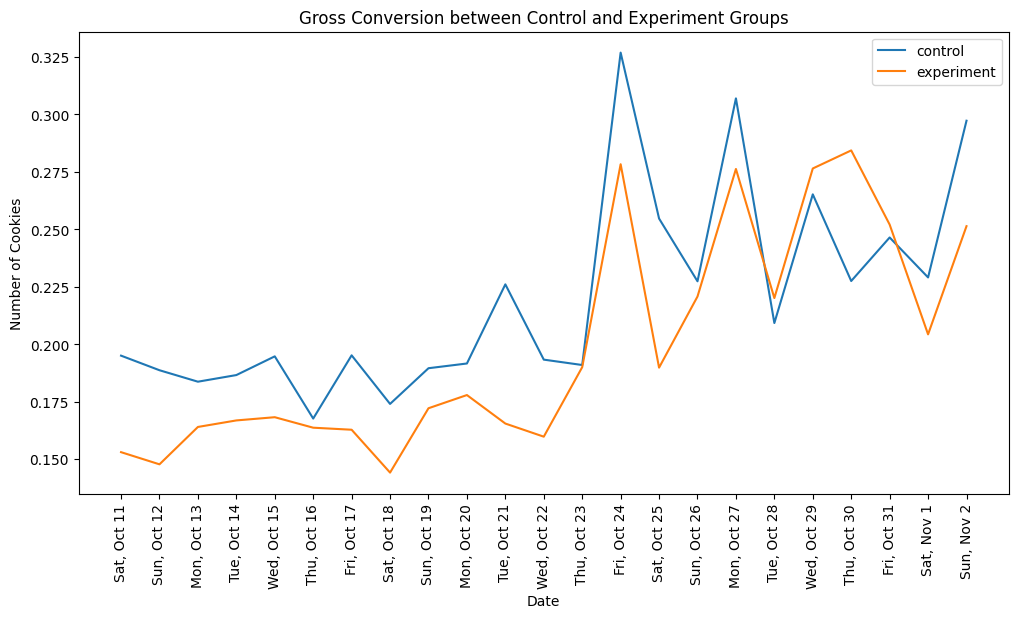

In [39]:
# evaluation metric: Gross Conversion
plt.figure(figsize=(12,6))
x = control_sliced['Date']
line1 = plt.plot(x ,control_sliced['Enrollments']/control_sliced['Clicks'],label = 'control')
line2 = plt.plot(x ,experiment_sliced['Enrollments']/experiment_sliced['Clicks'], label = 'experiment')
plt.xticks(rotation = 90)
plt.xlabel('Date')
plt.ylabel('Number of Cookies')
plt.title('Gross Conversion between Control and Experiment Groups')
plt.legend()

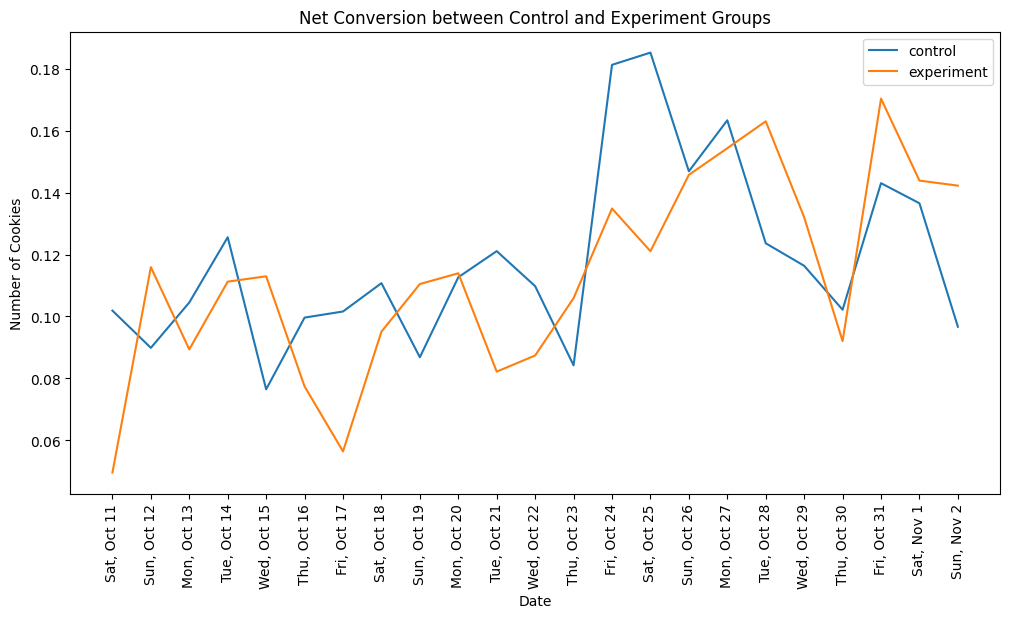

In [40]:
# evaluation metric: Net Conversion
plt.figure(figsize=(12,6))
x = control_sliced['Date']
line1 = plt.plot(x ,control_sliced['Payments']/control_sliced['Clicks'],label = 'control')
line2 = plt.plot(x ,experiment_sliced['Payments']/experiment_sliced['Clicks'], label = 'experiment')
plt.xticks(rotation = 90)
plt.xlabel('Date')
plt.ylabel('Number of Cookies')
plt.title('Net Conversion between Control and Experiment Groups')
plt.legend()

We can also see there is a huge peak on Oct.24th. According to we've mentioned a drop of click through probability on Oct.24th, we can infer that there is a larger number of pageviews. We recommend Udacity teams to do some further analysis on the whole traffic instead of this sample size.

### Check for Practical and Statistical Significance  
Now, both gross conversion and net conversion are probabilities, similar to click-through probability. Therefore, we can check them as we checked the click-through rate above. However, this time we will check for both practical(dmin) and statistical significance. 

In [46]:
# create a new dataframe
results = pd.DataFrame(index = ['Gross_Conversion'], 
                            columns=['CI_lower','CI_upper','obs','stats_sig?','dmin','prac_sig?'])

# dmin
results.dmin = [baseline.loc[4,'dmin']]

results

,CI_lower,CI_upper,obs,stats_sig?,dmin,prac_sig?
Gross_Conversion,NaN,NaN,NaN,NaN,-0.01,NaN


**Notice:** Because the payments and enrollments are None in the last 14 days, we should recalculate the real sample size for checking the evaluation metrics.

In [47]:
# recalculate the sample size
real_size = control_sliced['Pageviews'].sum() + experiment_sliced['Pageviews'].sum()
real_size 

np.int64(423525)

### lets do a two proportion z test for gross conversion 

#### we can do a z test here, because even though gross is binomially distributed, the sample size is large enough to approximate a normal distribution

In [49]:
import math

In [50]:
# Gross Conversion
nc = control_sliced['Clicks'].sum()
ne = experiment_sliced['Clicks'].sum()        
pc_hat_gc = control_sliced['Enrollments'].sum()/control_sliced['Clicks'].sum()
pe_hat_gc = experiment_sliced['Enrollments'].sum()/experiment_sliced['Clicks'].sum()                                         
# obs

# alpha = 0.05

#h0: pc_hat_gc = pe_hat_gc

diff =   pe_hat_gc - pc_hat_gc
results.loc['Gross_Conversion','obs'] = diff
# std
#pooled se for gc
p_hat_gc = ( control_sliced['Enrollments'].sum() + experiment_sliced['Enrollments'].sum() ) / (control_sliced['Clicks'].sum() + experiment_sliced['Clicks'].sum() ) 
se = math.sqrt( p_hat_gc * (1 - p_hat_gc ) * ( (1/nc) + (1/ne)) )

# Z statistic
z = (pe_hat_gc - pc_hat_gc) / se

# Two-tailed p-value
pval = 2 * (1 - norm.cdf(abs(z)))


print(f"Observed proportion: {p_hat_gc:.6f}")
print(f"Z-statistic: {z:.4f}")
print(f"P-value: {pval:.6f}")



Observed proportion: 0.208607
Z-statistic: -4.7018
P-value: 0.000003


### lets calculate the confidence interval around the difference between control and experiment Gross converisons

In [51]:
se = math.sqrt( (pc_hat_gc * (1 - pc_hat_gc ) * (1/nc) ) +  (pe_hat_gc * (1 - pe_hat_gc ) * (1/ne) )  )

z_crit = norm.ppf(0.975) # 1.96

# CI bounds
ci_lower = diff - z_crit * se
ci_upper = diff + z_crit * se

    
print(f"Difference in proportions: {diff:.4f}")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

results.loc['Gross_Conversion','CI_lower'], results.loc['Gross_Conversion','CI_upper'] = ci_lower, ci_upper

if results.loc['Gross_Conversion','CI_lower'] <= 0 <= results.loc['Gross_Conversion','CI_upper']:
    results.loc['Gross_Conversion','stats_sig?'] = 0
else: 
    results.loc['Gross_Conversion','stats_sig?'] = 1
    
if results.loc['Gross_Conversion','dmin'] < 0:
    if results.loc['Gross_Conversion','CI_upper'] <= results.loc['Gross_Conversion','dmin']:
        results.loc['Gross_Conversion','prac_sig?'] = 1 
    else: 
        results.loc['Gross_Conversion','prac_sig?'] = 0

if results.loc['Gross_Conversion','dmin'] > 0:
    if results.loc['Gross_Conversion','CI_lower'] >= results.loc['Gross_Conversion','dmin']:
        results.loc['Gross_Conversion','prac_sig?'] = 1 
    else: 
        results.loc['Gross_Conversion','prac_sig?'] = 0

results

Difference in proportions: -0.0206
95% CI: (-0.0291, -0.0120)


,CI_lower,CI_upper,obs,stats_sig?,dmin,prac_sig?
Gross_Conversion,-0.02912,-0.01199,-0.020555,1,-0.01,1


Now we can see the gross conversion decreased 2% in this A/B test, which was statiscally and practically significant.

## Results Interpretation & Recommendations

1. Gross conversion: the observed gross conversion in the experiment group is around 2.06% less than the gross conversion observed in the control group. Also, we see that values in the confidence interval are congruent with a negative effect. Since these values are less than the dmin (the smallest impact size considered to be business-related), the impact seems to be statiscally and practically significant. What is more, the impact of this test is much larger on Sundays while there is nearly no impact on Thursdays.

Based on these results, we can assume that this change may indeed help to set clearer expectations for students upfront. However, the results show that only gross conversion is practically and statiscally significant, not both gross and net converison. So we can further assume that this experiment is effective for decreasing the free trial enrollment, but payments cannot be converted so revenue increase for the business. Therefore, my recommend is not to launch, instead, we should do some further experiments.

# Follow-Up Experiment: How to Reduce Early Cancellations

Given that Udacity want to reduce early cancellation (early cancellation is the cancellation before the end of the 14-day free trial period that triggered the payment), we can consider from two ascpects: before the free trial enrollment and after the enrollment.

1. Before the free trial enrollment, our goal is to let users with more purchasing potential enroll meanwhile guide other users to access free course materials, which may attract more potential users in the long term. Therefore, based on the experiment we've done, this time we can improve the form regarding the time commitment. Firstly, this form is only used to filter students who cannot devote enough time, however, it does not contain prerequisites for the course. Some students may spend a fairly long time on this course but they are still frustrated due to lack of prerequisite knowledge. Therefore, we should also notice students the prerequisites for the course on the form. Secondly, we also need to convert non-purchasing potential student to obtain the free course materials. So if some students do not meet the commitment and prerequisites, the form should have a button that allows students to directly convert to access free course materials.  
   Therefore, we could launch this experiment again, but add the click through probability for the free course material as variant metric. (free course material click through probability: number of unique cookies to click the "free course material" button divided by number of unique cookies to view the course overview page).  
   A successful experiment would be a significant decrease in the total conversion and a significant increase in the net conversion rate and the free course materials click through probability.  
    
    
2. For the users who have already enrolled, it is necessary to improve their user experience and make them more satisfied, so that they are willing to stay. Due to the limited coaching resources, I think the interaction between students can be increased. An effective method might be to have students led by a tutor form a group. Students can learn from and help each other, and it may also have a potential sense of competition. In this way, the group can make students more motivated and have a sense of belonging, which may lead to retention.  

     - The experiment design:
       For the students who have enrolled, randomly assgin them to experiment group and control group. In the experiment group, students will be assigned to the groups according to their mentors. And in the control group, students will not be assigned.
         
     - Unit of Diversion: the unit of diversion will be user-ids, because this experiment will occur after students enrolling the free trial where they should create accounts or sign in.
     
     - Hypothesis:
       Null Hypotheis: Setting groups will not increase significantly the number of students who will continue their course after 14 days free trial.
       Alternative Hypothesis: Setting groups will increase significantly the number of students who will continue their course after 14 days free trial.
       
     - Invariant Metrics: the invariant metric should be the number of user-ids as it is the data that we can collect before the change and it is dependent on the unit of diversion for this experiment.
     
     - Evaluation Metrics: the evaluation metric will be rentention. Retention is the number of user-ids to remain enrolled past the 14-day boundary (and thus make at least one payment) divided by number of user-ids to complete checkout. 
     
   If a statistically and practically significant positive change in retention is observed, given the sanity check is passed, assuming the resources and cost is acceptable for Udacity, then we can launch this experiment.

   